# **Extraindo dados**

In [ ]:
import pandas as pd

dados = pd.read_csv('/content/Telecom_tratado.csv')
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7267 non-null   object 
 1   evasao                7267 non-null   bool   
 2   genero                7267 non-null   object 
 3   idoso                 7267 non-null   bool   
 4   tem_parceiro          7267 non-null   bool   
 5   tem_dependentes       7267 non-null   bool   
 6   meses_contrato        7267 non-null   int64  
 7   servico_telefone      7267 non-null   bool   
 8   multiplas_linhas      7267 non-null   bool   
 9   servico_internet      7267 non-null   object 
 10  seguranca_online      7267 non-null   bool   
 11  backup_online         7267 non-null   bool   
 12  protecao_dispositivo  7267 non-null   bool   
 13  suporte_tecnico       7267 non-null   bool   
 14  streaming_tv          7267 non-null   bool   
 15  streaming_filmes     

In [ ]:
# Excluindo colunas desnecessárias

dados = dados.drop(columns=['id_cliente'])
dados.head()

,evasao,genero,idoso,tem_parceiro,tem_dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,valor_total,valor_diario
0,False,female,False,True,True,9,True,False,dsl,False,...,False,True,True,False,one year,True,mailed check,65.6,593.30,2.19
1,False,male,False,False,False,9,True,True,dsl,False,...,False,False,False,True,month,False,mailed check,59.9,542.40,2.00
2,True,male,False,False,False,4,True,False,fiber optic,False,...,True,False,False,False,month,True,electronic check,73.9,280.85,2.46
3,True,male,True,True,False,13,True,False,fiber optic,False,...,True,False,True,True,month,True,electronic check,98.0,1237.85,3.27
4,True,female,True,True,False,3,True,False,fiber optic,False,...,False,True,True,False,month,True,mailed check,83.9,267.40,2.80


# **Tratando colunas Categóricas e Booleanas**

In [ ]:
# Transormando booleanas em int

col_bool = dados.select_dtypes(include='bool').columns
dados[col_bool] = dados[col_bool].astype(int)
dados.head()

,evasao,genero,idoso,tem_parceiro,tem_dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,valor_total,valor_diario
0,0,female,0,1,1,9,1,0,dsl,0,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0,male,0,0,0,9,1,1,dsl,0,...,0,0,0,1,month,0,mailed check,59.9,542.40,2.00
2,1,male,0,0,0,4,1,0,fiber optic,0,...,1,0,0,0,month,1,electronic check,73.9,280.85,2.46
3,1,male,1,1,0,13,1,0,fiber optic,0,...,1,0,1,1,month,1,electronic check,98.0,1237.85,3.27
4,1,female,1,1,0,3,1,0,fiber optic,0,...,0,1,1,0,month,1,mailed check,83.9,267.40,2.80


In [ ]:
# Tranformando categóricas

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

col_categoricas = ['genero', 'servico_internet', 'tipo_contrato', 'metodo_pagamento']
one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown = 'ignore'),
    col_categoricas),
    remainder='passthrough')
dados = one_hot_enc.fit_transform(dados)
dados = pd.DataFrame(dados, columns=one_hot_enc.get_feature_names_out())
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   onehotencoder__genero_female                             7267 non-null   float64
 1   onehotencoder__genero_male                               7267 non-null   float64
 2   onehotencoder__servico_internet_dsl                      7267 non-null   float64
 3   onehotencoder__servico_internet_fiber optic              7267 non-null   float64
 4   onehotencoder__servico_internet_no                       7267 non-null   float64
 5   onehotencoder__tipo_contrato_month                       7267 non-null   float64
 6   onehotencoder__tipo_contrato_one year                    7267 non-null   float64
 7   onehotencoder__tipo_contrato_two year                    7267 non-null   float64
 8   onehotencoder__metodo_pagame

In [ ]:
# Renomeia todas as colunas
dados.columns = [c.split('__')[-1] for c in dados.columns]
dados.head()

,genero_female,genero_male,servico_internet_dsl,servico_internet_fiber optic,servico_internet_no,tipo_contrato_month,tipo_contrato_one year,tipo_contrato_two year,metodo_pagamento_bank transfer automatic,metodo_pagamento_credit card automatic,...,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,fatura_digital,valor_mensal,valor_total,valor_diario
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.19
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,2.00
2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.46
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.27
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.80


In [ ]:
# Verificar proporção de evasão

print(dados['evasao'].value_counts(normalize=True) * 100)

evasao
0.0    74.280996
1.0    25.719004
Name: proportion, dtype: float64


# **Preparando dados de treino com SMOTE**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# Separar X e y
X = dados.drop(columns=['evasao'])
y = dados['evasao']

# Dividir em Treino e Teste PRIMEIRO
# O 'stratify=y' garante que a proporção original de evasão seja mantida na divisão
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **Normalização do modelo**


In [ ]:
# Normalizar
scaler = StandardScaler()
# Importante: Fazemos o 'fit' APENAS nos dados de treino para evitar vazamento
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Apenas 'transform' no teste

# 4. Aplicar o SMOTE APENAS nos dados de treino já normalizados
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribuição Treino ANTES: {Counter(y_train)}")
print(f"Distribuição Treino DEPOIS (SMOTE): {Counter(y_train_resampled)}")

Distribuição Treino ANTES: Counter({0.0: 4318, 1.0: 1495})
Distribuição Treino DEPOIS (SMOTE): Counter({0.0: 4318, 1.0: 4318})


# **Análise de Correlação**

/tmp/ipykernel_294/984747186.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacao_alvo.values, y=correlacao_alvo.index, palette='coolwarm')


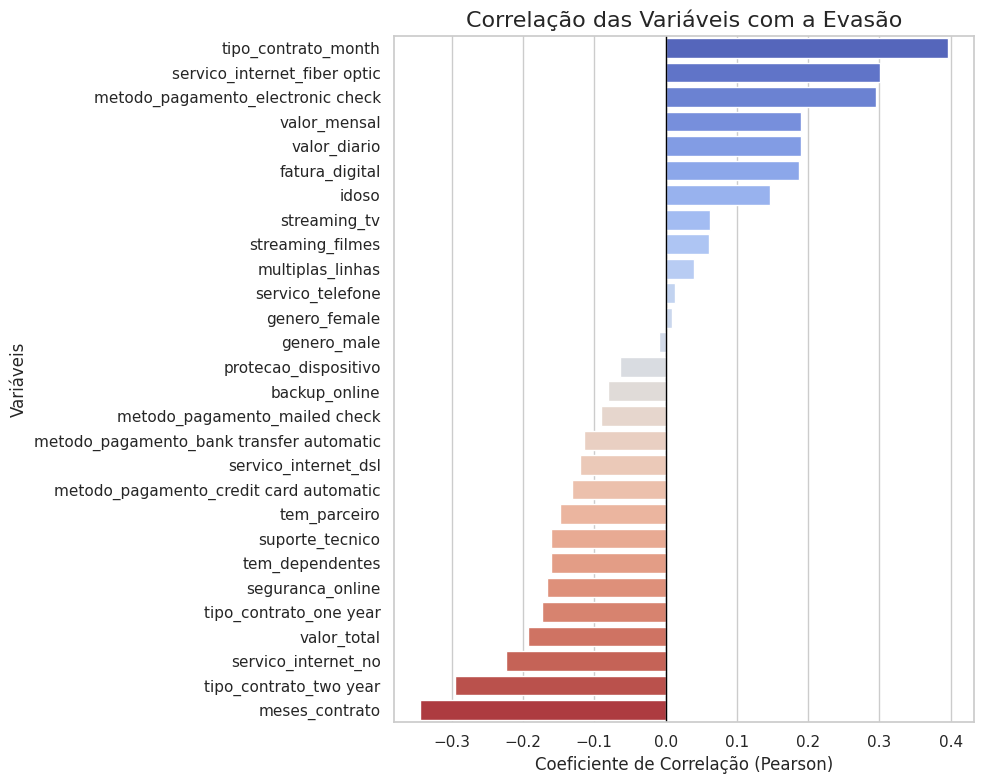

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcula a correlação de todas as variáveis apenas com 'evasao'
# O .drop('evasao') tira a correlação dela com ela mesma
correlacao_alvo = dados.corr()['evasao'].drop('evasao')

# Ordena os valores do maior para o menor
correlacao_alvo = correlacao_alvo.sort_values(ascending=False)

# Cria o gráfico de barras
plt.figure(figsize=(10, 8))
sns.barplot(x=correlacao_alvo.values, y=correlacao_alvo.index, palette='coolwarm')

plt.title('Correlação das Variáveis com a Evasão', fontsize=16)
plt.xlabel('Coeficiente de Correlação (Pearson)')
plt.ylabel('Variáveis')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

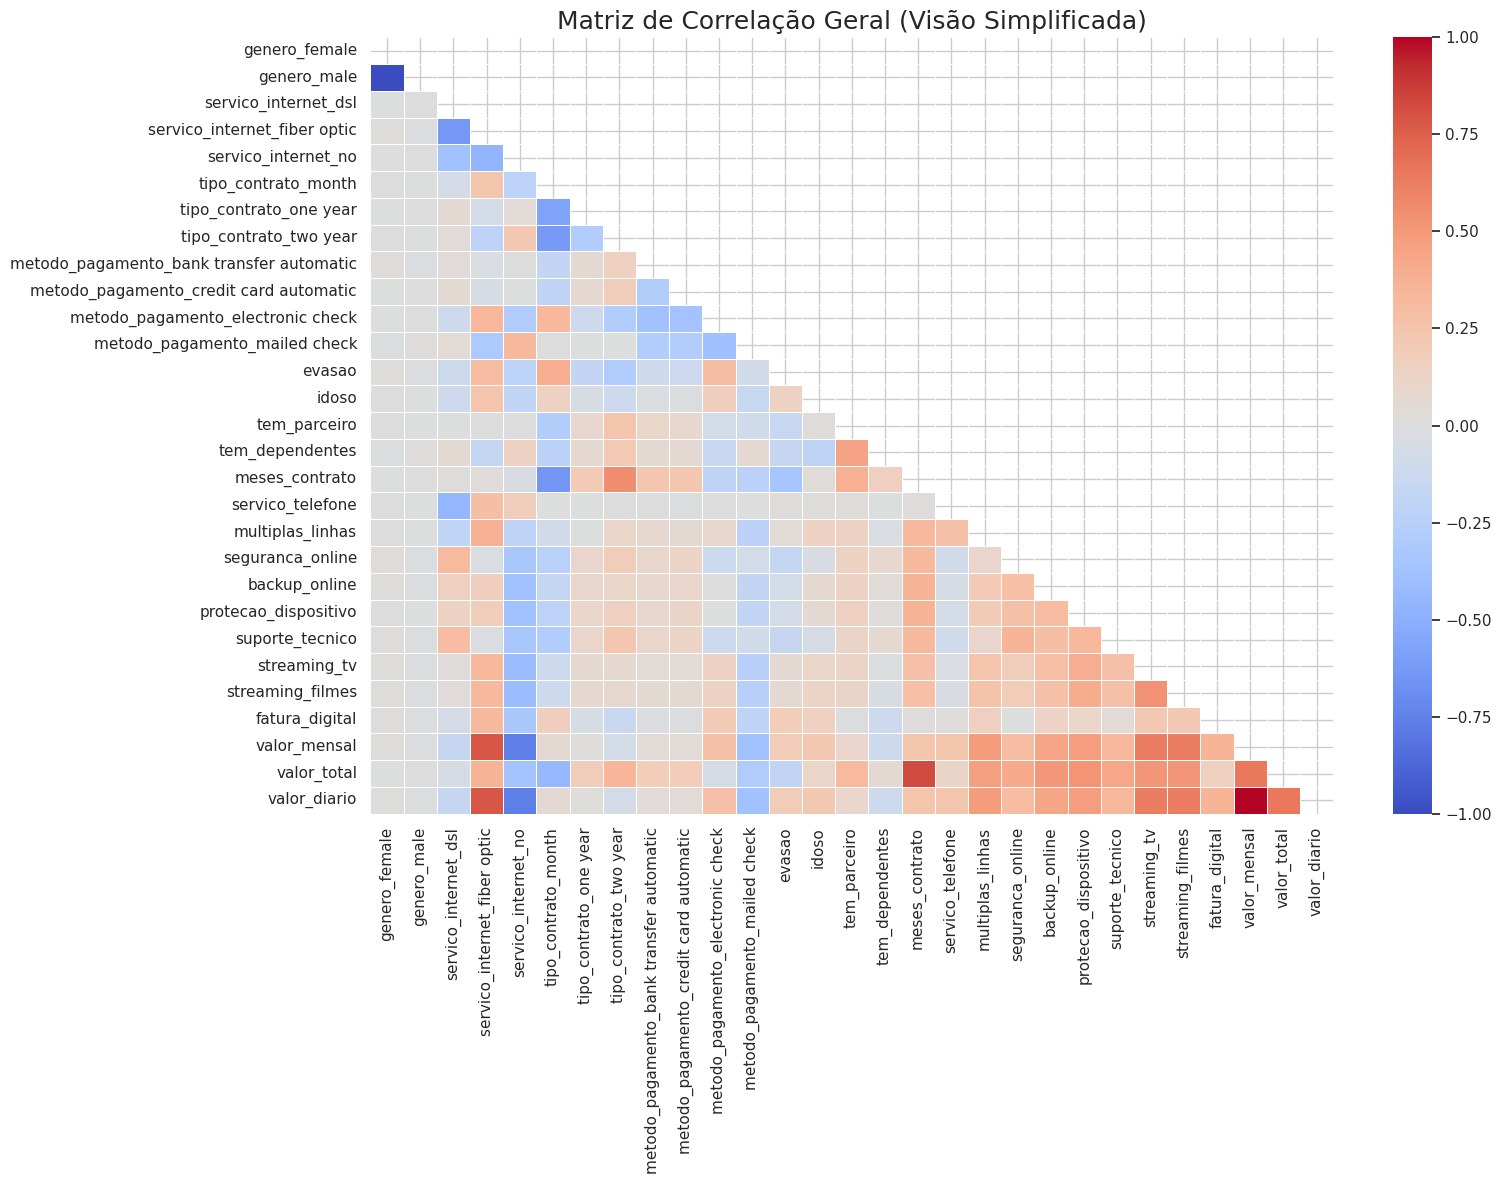

In [ ]:
import numpy as np

# Aumenta bastante o tamanho da figura
plt.figure(figsize=(16, 12))
matriz_correlacao = dados.corr()

# Cria uma "máscara" para esconder a metade superior do triângulo
mascara = np.triu(np.ones_like(matriz_correlacao, dtype=bool))

# Gera o heatmap SEM os números (annot=False) e com a máscara
sns.heatmap(matriz_correlacao,
            mask=mascara,
            annot=False,
            cmap='coolwarm',
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Matriz de Correlação Geral (Visão Simplificada)', fontsize=18)
plt.tight_layout()
plt.show()

# **Análises Direcionadas**

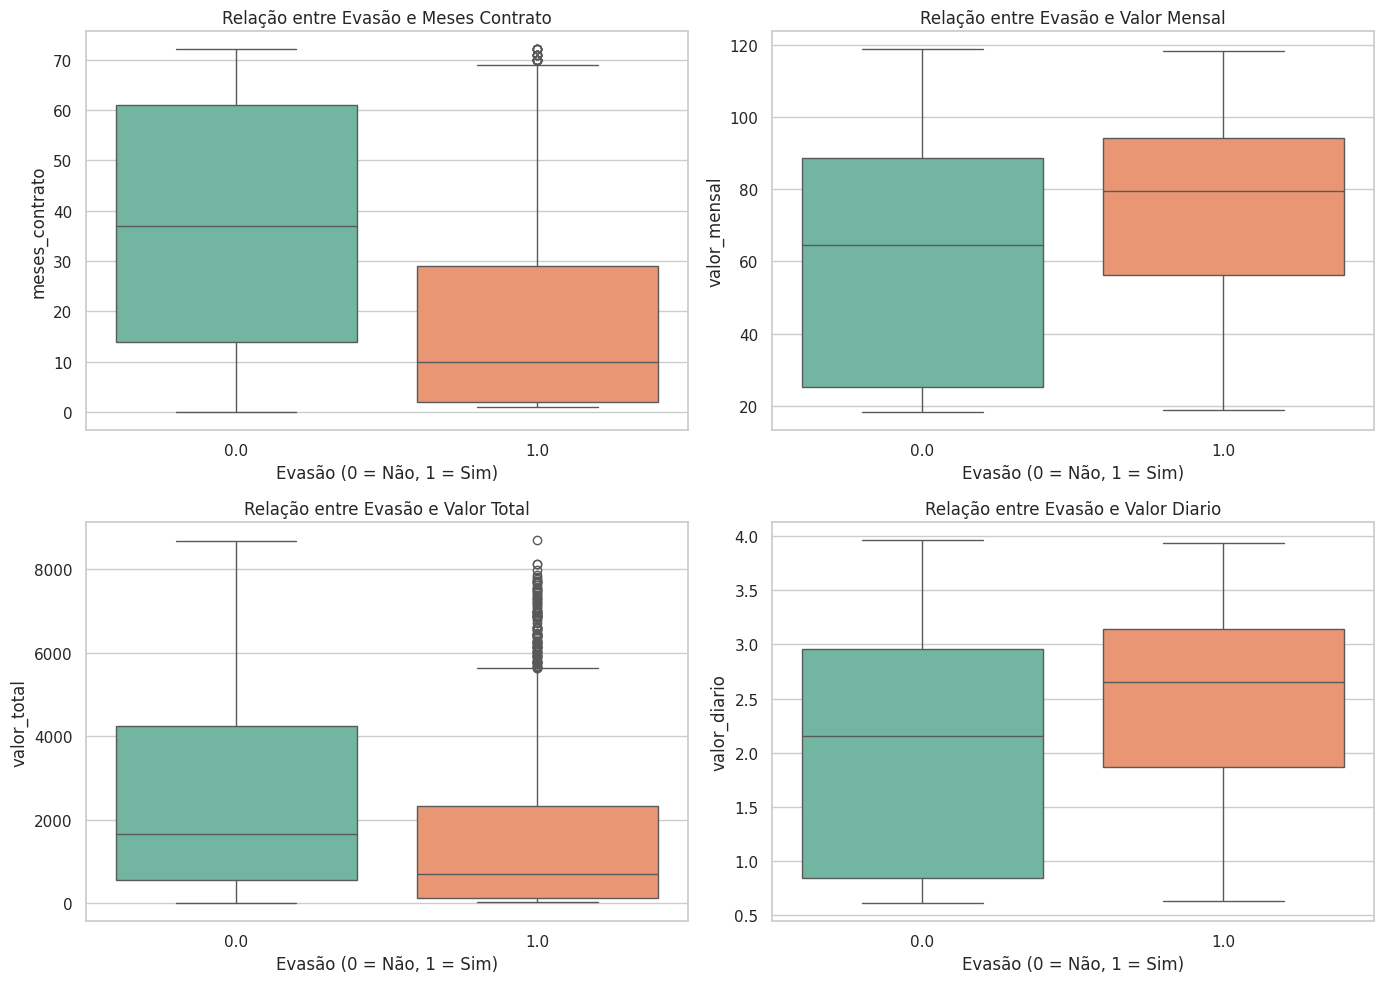

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Defina manualmente quais são as suas colunas numéricas contínuas
# (Ajuste essa lista com base nas colunas reais do seu dataset que não são 0 e 1)
colunas_continuas = ['meses_contrato', 'valor_mensal', 'valor_total', 'valor_diario']

# 2. Configurar o tamanho da figura para acomodar todos os gráficos
# Vamos criar uma grade com 2 colunas e quantas linhas forem necessárias
num_vars = len(colunas_continuas)
linhas = (num_vars + 1) // 2

fig, axes = plt.subplots(nrows=linhas, ncols=2, figsize=(14, 5 * linhas))
axes = axes.flatten() # Achata o array de eixos para facilitar o loop

# 3. Gerar um boxplot para cada variável contínua
for i, coluna in enumerate(colunas_continuas):
    sns.boxplot(
        data=dados,
        x='evasao',
        y=coluna,
        ax=axes[i],
        palette='Set2',
        hue='evasao', # Adicionado hue para evitar warnings no Seaborn atual
        legend=False
    )

    axes[i].set_title(f'Relação entre Evasão e {coluna.replace("_", " ").title()}', fontsize=12)
    axes[i].set_xlabel('Evasão (0 = Não, 1 = Sim)')
    axes[i].set_ylabel(coluna)

# 4. Remove eixos vazios caso o número de variáveis seja ímpar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Separação dos Dados**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separando as features (X) da variável alvo (y)
X = dados.drop(columns=['evasao'])
y = dados['evasao']

# 2. Fazendo a divisão 70/30
# O parâmetro stratify=y é vital aqui: ele garante que a mesma proporção
# de evasão (ex: 20% de evasão e 80% de não evasão) seja mantida tanto no treino quanto no teste!
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% para teste, 70% para treino
    random_state=42,    # Garante que a divisão seja sempre a mesma ao rodar o código novamente
    stratify=y          # Mantém a proporção da variável alvo
)

# 3. Conferindo o tamanho dos conjuntos gerados
print(f"Tamanho do conjunto de Treino (X_train): {X_train.shape[0]} amostras ({X_train.shape[0]/dados.shape[0]*100:.0f}%)")
print(f"Tamanho do conjunto de Teste (X_test): {X_test.shape[0]} amostras ({X_test.shape[0]/dados.shape[0]*100:.0f}%)")

Tamanho do conjunto de Treino (X_train): 5086 amostras (70%)
Tamanho do conjunto de Teste (X_test): 2181 amostras (30%)


# **Criação de Modelos**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# --- PREPARAÇÃO COM NORMALIZAÇÃO (Para Regressão Logística) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aplicando SMOTE nos dados normalizados
smote = SMOTE(random_state=42)
X_train_resampled_scaled, y_train_resampled_scaled = smote.fit_resample(X_train_scaled, y_train)

# --- PREPARAÇÃO SEM NORMALIZAÇÃO (Para Random Forest) ---
# Aplicando SMOTE direto nos dados originais de treino
# (Nota: o SMOTE usa KNN internamente, mas na prática com Random Forest,
# a diferença gerada pela falta de normalização antes do SMOTE costuma ser absorvida pela robustez das árvores).
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# ==========================================
# TREINAMENTO 1: REGRESSÃO LOGÍSTICA
# ==========================================
print("--- Resultados: Regressão Logística ---")
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
# Treina com dados normalizados e balanceados
modelo_lr.fit(X_train_resampled_scaled, y_train_resampled_scaled)

# Prevê usando os dados de teste normalizados
y_pred_lr = modelo_lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))



--- Resultados: Regressão Logística ---
              precision    recall  f1-score   support

         0.0       0.92      0.73      0.81      1620
         1.0       0.51      0.81      0.62       561

    accuracy                           0.75      2181
   macro avg       0.71      0.77      0.72      2181
weighted avg       0.81      0.75      0.77      2181



In [ ]:
# ==========================================
# TREINAMENTO 2: RANDOM FOREST
# ==========================================
print("\n--- Resultados: Random Forest ---")
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)
# Treina com dados balanceados, mas SEM normalização
modelo_rf.fit(X_train_resampled, y_train_resampled)

# Prevê usando os dados de teste originais (sem normalização)
y_pred_rf = modelo_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


--- Resultados: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86      1620
         1.0       0.60      0.49      0.54       561

    accuracy                           0.78      2181
   macro avg       0.72      0.69      0.70      2181
weighted avg       0.77      0.78      0.78      2181



# **Avaliação dos Modelos**

Conforme os resultados gerados, o desempenho do modelo Random Forest foi:
- Acurácia: 0.78 (78%)
- Precisão (Evasão - Classe 1.0): 0.60
- Recall (Evasão - Classe 1.0): 0.49
- F1-score (Evasão - Classe 1.0): 0.54

**Análise Crítica e Comparação**

Melhor Desempenho: O modelo Random Forest apresentou uma acurácia sólida de 78%, mas o Recall de 49% indica que ele ainda deixa passar cerca de metade dos clientes que realmente irão evadir. Para um problema de churn, o Recall é a métrica mais crítica, pois é preferível identificar um cliente fiel como potencial evasor (falso positivo) do que perder um cliente sem aviso prévio.

**Overfitting/Underfitting**

Não há sinais claros de overfitting severo, pois a performance de teste está equilibrada. Entretanto, a baixa capacidade de capturar a classe positiva (Recall) sugere que o modelo pode estar sofrendo de Underfitting em relação aos padrões de evasão, possivelmente devido ao desequilíbrio original dos dados (apenas 25,7% de evasão no dataset original).

# **Análise da Importância de Variáveis**

Com base na análise de correlação de Pearson realizada no projeto, os fatores que mais contribuem para a previsão são:

**Variáveis com Forte Correlação Positiva (Aumentam a Evasão)**

- tipo_contrato_month (Contrato Mensal): É o fator de maior peso. Clientes sem fidelidade anual têm maior facilidade para sair.

- servico_internet_fiber_optic (Fibra Óptica): Surpreendentemente, clientes de fibra têm maior tendência à evasão, o que pode indicar problemas de preço ou instabilidade técnica no serviço.

- metodo_pagamento_electronic_check: Este método de pagamento está fortemente associado ao churn. Variáveis com Forte

**Correlação Negativa (Diminuem a Evasão)**

- meses_contrato (Tenure): Quanto mais tempo o cliente permanece na empresa, menor a chance de ele sair.

- tipo_contrato_two_year: Contratos de longo prazo são os maiores retentores de clientes.

- suporte_tecnico: A presença de suporte técnico disponível reduz drasticamente a chance de evasão.

# **Conclusão**

**1. Introdução**

Este relatório apresenta a análise de dados e a modelagem preditiva desenvolvidas para a TelecomX, focando na identificação de padrões de evasão de clientes. O objetivo principal foi construir um modelo capaz de antecipar o cancelamento de serviços, permitindo ações preventivas de retenção.


**2. Metodologia e Modelagem**

O pipeline de dados envolveu o tratamento de variáveis categóricas via One-Hot Encoding e a normalização de atributos numéricos. Para mitigar o desequilíbrio de classes (churn vs. retenção), aplicou-se a técnica SMOTE (Synthetic Minority Over-sampling Technique) exclusivamente sobre os dados de treinamento, garantindo a integridade dos testes. Foram testados diversos algoritmos, sendo o Random Forest o selecionado para a análise final devido ao seu equilíbrio entre precisão e robustez.

**3. Análise de Performance**

O modelo alcançou uma acurácia de 78%. No entanto, a análise profunda das métricas revela um Recall de 49% para a classe de evasão. Isso indica que, embora o modelo seja preciso ao classificar clientes fiéis, ele ainda apresenta um desafio em capturar todos os potenciais evasores. Este cenário é típico de modelos que buscam evitar falsos positivos, mas sugere uma oportunidade de ajuste fino em hiperparâmetros para aumentar a sensibilidade do modelo.

**4. Principais Drivers de Evasão**

A análise de correlação identificou os pilares que sustentam ou fragilizam a permanência do cliente:

- Instabilidade Contratual: Clientes com contratos mensais (month-to-month) possuem a maior propensão ao cancelamento.

- Tecnologia de Acesso: Usuários de Fibra Óptica apresentam taxas de churn superiores aos de DSL, indicando uma possível fricção entre a expectativa de performance e o valor cobrado.

- Barreiras de Retenção: O tempo de casa (tenure) e contratos de longo prazo (dois anos) atuam como os principais fatores de proteção contra a evasão.

**5. Conclusão e Recomendações Estratégicas**

Para reverter o cenário de churn, recomenda-se:

- Conversão Contratual: Implementar campanhas de "upgrade" para contratos anuais focadas no segmento mensal.

- Plano de Qualidade na Fibra: Revisar o suporte técnico e a estabilidade da rede de fibra óptica para alinhar a entrega ao valor do serviço.

- Foco no Onboarding: Intensificar o relacionamento com o cliente nos primeiros 6 meses, período de maior vulnerabilidade detectado pelo modelo.